<a href="https://colab.research.google.com/github/PablGb/Analise_de_Dados-Qualidade_do_Ar/blob/main/Qualidade_do_Ar_An%C3%A1lise_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Baixando a base de Dados


*   Pesquisar artigos, sites,

*   Resolver problema de dados mistos na coluna 6 dos dados3.

*   Ver o que fazer com dados NaN.

*   Pesquisar como é dado o IQAR, e como ele se relaciona com aa base de dados.

*   alguns valores de PRESSÃO e alguns medidores de partícula (como o MATERIAL PARTICULADO COM DIÂMETRO DE ATÉ 10 µm - MP10 (), Partículas Totais em Suspensão - PTS (1.985.000), MATERIAL PARTICULADO COM DIÂMETRO DE ATÉ 2,5 µm - MP2,5) chegam a 1.000.000 (Ex: 1.351.510 hectoPascal na linha 133 do dados1). É preciso verficar se esses valores representam 1.000.000 (milhão) ou é 1.000,000 (mil).

*   Fazer Automodelo para estações que estão quebradas fazendo um tipo de imputação de dados.

*   Análise temporal por região.









Base de dados: https://dados.gov.br/dados/conjuntos-dados/ar-puro-monitorar

Relatório de 2023 de qualidade do ar: https://www.gov.br/mma/pt-br/assuntos/meio-ambiente-urbano-recursos-hidricos-qualidade-ambiental/qualidade-do-ar/relatorio-anual/relatorio-anual-da-qualidade-do-ar-2023.pdf

GuiaTecnicoparaQualidadedoAr: https://www.gov.br/mma/pt-br/acesso-a-informacao/acoes-e-programas/programa-projetos-acoes-obras-atividades/agendaambientalurbana/ar-puro/GuiaTecnicoparaQualidadedoAr.pdf

Cetrel Visualização de dados atuais do monitoramento do Ar: https://www.cetrel.com.br/monitoramento-ar/

RESOLUÇÃO CONAMA: https://conama.mma.gov.br/index.php?option=com_sisconama&task=documento.download&id=25810

TCC de PARTÍCULAS TOTAIS EM SUSPENSÃO: UM ESTUDO DE CASO EM BELÉM – PARÁ: https://bdta.ufra.edu.br/jspui/bitstream/123456789/3597/1/TCC%20-%20ELMERSON%20BRUNO%20-%20Part%C3%ADculas%20totais%20em%20suspens%C3%A3o%20um%20estudo%20de%20caso%20em%20Bel%C3%A9m%20%E2%80%93%20Par%C3%A1.pdf

#Tratamento de Dados

In [ ]:
import pandas as pd

Verificando o enconding para para leitura pela biblioteca Pandas

In [ ]:
import chardet

In [ ]:
with open("/content/Dados_monitorar_jan_mar_22-11-2022 DQAA.csv", 'rb') as f:
    result = chardet.detect(f.read(100000))  # lê uma amostra
print(result)

{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}


In [ ]:
with open("/content/Dados_monitorar_jan_mar_22-11-2022 DQAA.csv", "r", encoding="ISO-8859-1") as f:
    for i in range(5):
        print(f.readline())

Nome do Município;Estado;Nome da Estação;Item_monitorado;Sigla;Concentracao;iqar;Data;Hora;Situação;

Conceição do Mato Dentro;MG;Aeroporto CMD;Material Particulado com diâmetro de até 10 µm;MP10;42.000;26.400;31/03/2022;23:30;VA;

Conceição do Mato Dentro;MG;Aeroporto CMD;Material Particulado com diâmetro de até 2,5 µm;MP2,5;8.000;12.800;31/03/2022;23:30;VA;

Conceição do Mato Dentro;MG;Aeroporto CMD;Partículas Totais em Suspensão;PTS;63.000;;31/03/2022;23:30;VA;

Barra Longa;MG; Barra Longa Centro;Material Particulado com diâmetro de até 10 µm;MP10;28.000;38.400;31/03/2022;23:30;VA;



In [ ]:
with open("/content/Lista Estações MonitorAr - Nov-2022.csv", "r", encoding="UTF-8-SIG") as f:
    for i in range(5):
        print(f.readline())

Código IBGE do Município;Nome do Município;Estado;ID da Estação;Nome da Estação;Item medido;Status da estação;Tipo da estação;Latitude;Longitude;no_fonte_dados;

2905701;Camaçari;BA;182;AREIAS;SO₂;Em Operação;Automática;-12,801148;-38,223966;CETREL e Inema;

2905701;Camaçari;BA;184;MACHADINHO;CH, CO, DV, NH₃, NO, NO₂, NOx, O₃, PRESS, RAD, SO₂, TEMP, U, VV;Em Operação;Automática;-12,756957;-38,284080;CETREL e Inema;

2905701;Camaçari;BA;185;CÂMARA;DV, NO, NO₂, NOx, O₃, SO₂, VV;Em Operação;Automática;-12,706030;-38,321377;CETREL e Inema;

2905701;Camaçari;BA;187;GRAVATÁ;CH, CH₄, CO, DV, ERT, HCT, MP₁₀, NH₃, NO, NO₂, NOx, PRESS, RAD, SO₂, TEMP, U, VV;Em Operação;Automática;-12,686376;-38,333604;CETREL e Inema;



In [ ]:
with open('/content/Dados_monitorar_jul_nov_22-11-2022 DQAA.csv', 'rb') as f:
  result = chardet.detect(f.read(200000))  # lê uma amostra
print(result)

{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}


In [ ]:
with open("/content/Dados_monitorar_jul_nov_22-11-2022 DQAA.csv", "r", encoding="ISO-8859-1") as f:
    for i in range(6):
        print(f.readline())

Nome do Município;Estado;Nome da Estação;Item_monitorado;Sigla;Concentracao;iqar;Data;Hora;Situação

Camaçari;BA;CÂMARA;Dióxido de Enxofre;SO2;0.891;3.400;22/11/2022;11:00;VA

Camaçari;BA;CÂMARA;Dióxido de Nitrogênio;NO2;5.670;5.120;22/11/2022;11:00;VA

Camaçari;BA;CÂMARA;Direção do vento;DV;116.732;;22/11/2022;11:00;VA

Camaçari;BA;CÂMARA;Óxido Nítrico;NO;6.156;;22/11/2022;11:00;VA

Camaçari;BA;CÂMARA;Óxidos de Nitrogênio;NOx;11.846;;22/11/2022;11:00;VA



In [ ]:
with open('/content/Dados_monitorar_abr_jun_22-11-2022 DQAA.csv', 'rb') as f:
  result = chardet.detect(f.read(200000))  # lê uma amostra
print(result)

{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}


In [ ]:
with open("/content/Lista Estações MonitorAr - Nov-2022.csv", 'rb') as f:
    result = chardet.detect(f.read(200000))  # lê uma amostra
print(result)

{'encoding': 'UTF-8-SIG', 'confidence': 1.0, 'language': ''}


Realizando Leitura dos dados

In [ ]:
import pandas as pd

dados1 = pd.read_csv("/content/Dados_monitorar_jan_mar_22-11-2022 DQAA.csv", encoding = "ISO-8859-1", sep = ";")

In [ ]:
dados1

,Nome do Município,Estado,Nome da Estação,Item_monitorado,Sigla,Concentracao,iqar,Data,Hora,Situação,Unnamed: 10
0,Conceição do Mato Dentro,MG,Aeroporto CMD,Material Particulado com diâmetro de até 10 µm,MP10,42.000,26.4,31/03/2022,23:30,VA,NaN
1,Conceição do Mato Dentro,MG,Aeroporto CMD,"Material Particulado com diâmetro de até 2,5 µm","MP2,5",8.000,12.8,31/03/2022,23:30,VA,NaN
2,Conceição do Mato Dentro,MG,Aeroporto CMD,Partículas Totais em Suspensão,PTS,63.000,NaN,31/03/2022,23:30,VA,NaN
3,Barra Longa,MG,Barra Longa Centro,Material Particulado com diâmetro de até 10 µm,MP10,28.000,38.4,31/03/2022,23:30,VA,NaN
4,Barra Longa,MG,Barra Longa Centro,"Material Particulado com diâmetro de até 2,5 µm","MP2,5",10.000,19.2,31/03/2022,23:30,VA,NaN
...,...,...,...,...,...,...,...,...,...,...,...
733103,Rio de Janeiro,RJ,Tijuca,Radiação solar,RAD,31.330,NaN,01/01/2022,00:00,VA,NaN
733104,Rio de Janeiro,RJ,Tijuca,Temperatura,TEMP,22.170,NaN,01/01/2022,00:00,VA,NaN
733105,Rio de Janeiro,RJ,Tijuca,Temperatura interna (°C),TEMPI,28.800,NaN,01/01/2022,00:00,VA,NaN
733106,Rio de Janeiro,RJ,Tijuca,Umidade relativa,UR,12.630,NaN,01/01/2022,00:00,VA,NaN


In [ ]:
dados1.info()

dados1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733108 entries, 0 to 733107
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Nome do Município  733108 non-null  object 
 1   Estado             733108 non-null  object 
 2   Nome da Estação    733108 non-null  object 
 3   Item_monitorado    733108 non-null  object 
 4   Sigla              733108 non-null  object 
 5   Concentracao       733108 non-null  object 
 6   iqar               390316 non-null  float64
 7   Data               733108 non-null  object 
 8   Hora               733108 non-null  object 
 9   Situação           733108 non-null  object 
 10  Unnamed: 10        181712 non-null  object 
dtypes: float64(1), object(10)
memory usage: 61.5+ MB


,iqar
count,390316.000000
mean,14.779997
std,11.911713
min,0.000000
25%,6.000000
50%,13.000000
75%,20.800000
max,247.400000


In [ ]:
dados1['Item_monitorado'].value_counts()

,count
Item_monitorado,
Material Particulado com diâmetro de até 10 µm,82858
"Material Particulado com diâmetro de até 2,5 µm",52795
Ozônio,42645
Partículas Totais em Suspensão,28321
Dióxido de Nitrogênio,20051
Monóxido de Carbono,19271
Dióxido de Enxofre,17530
Vento,15922
Direção do vento,15908


###Conversão das medidas de concentração dos dados:





CH₄ Metano ~ 10³ µg/m³ → Converter para grandeza em milhares (basta tirar o ponto).

O₃ (Ozônio) ~ 10 a 60 µg/m³ → Converter o ponto tratando como vírgula (ponto = vírgula).

MP10 Material Particulado ≤10 µm µg/m³
~ 10 a 50 µg/m³ → ponto = vírgula.

MP2,5 Material Particulado ≤2,5 µm µg/m³
~ 10 a 50 µg/m³ → ponto = vírgula.

PTS Partículas Totais em Suspensão µg/m³ ~ 10 a 50 µg/m³ → ponto = vírgula. (PROBLEMA DE DADOS INVÁLIDOS MUITO ALTOS COM DOIS PONTOS)

NO₂ Dióxido de Nitrogênio µg/m³ ~ 20–100 µg/m³ → ponto = vírgula. (No entanto verificar como vão ficar os dados, suspeita de dados muito abaixo do que deveriam ser, talvez o ponto deveria ser colocado uma casa à direita 1.590 µg/m³ → 15.90 µg/m³)

CO Monóxido de Carbono ppm ~ 1 ppm → ponto = vírgula.

SO₂ Dióxido de Enxofre µg/m³ ~ < 10 µg/m³ → ponto = vírgula. (No entanto alguns valores de São Paulo estão bem altos, chegando a aproximandamente 20 µg/m³ )

VV Velocidade do vento km/h ~ 3–15 km/h → ponto = vírgula. (Os valores parecem estar mais abaixo do que deveriam, talvez devesse estar um ponto à esquerda).

DV Direção do vento (°) ~ 0–360° → ponto = vírgula.

TEMP Temperatura °C ≈ 20 °C → vírgula = ponto.

NO Óxido Nítrico µg/m³ ~ < 50 µg/m³ → vírgula = ponto. (Os valores estão um pequenos quando comparados com as referências, talves o valor verdadeiro seja passando o ponto uma casa à esquerda).

NOₓ Óxidos de Nitrogênio µg/m³ ~ 20–150 µg/m³ → vírgula = ponto. (Valores abaixo do limite)

PRESS Pressão Atmosférica hPa ~ 1010–1020 hPa → Tirar 1° ponto; 2° ponto = vírgula.

RAD Radiação Solar W/m² ~ Até 1000 W/m² → vírgula = ponto.

UR Umidade Relativa % ≈ 70–80% → vírgula = ponto.

TEMPI Temperatura interna (°C) ≈ 48,2°-10,0°C → vírgula = ponto. (Não aparece no dicionário)

CH Chuva mm ~ 999 mm → vírgula = ponto. (Provavelmente os dados são acumulativos).

ERT Enxofre Reduzido Total µg/m³ ~ 200 µg/m³ → ponto = vírgula.

U Umidade % → ponto = vírgula.

HCT Hidrocarbonetos Totais µg/m³ ~ 1.341 significa 1,341 µg/m³ → ponto = vírgula.

NH₃ Amônia µg/m³ ~ < 10 µg/m³ → ponto = vírgula.

Hidrocarbonetos não Metano µg/m³ ~ 1.341 significa 1,341 µg/m³ → ponto = vírgula.

In [ ]:
def corrigir_formato_estranho(valor):
    valor = str(valor) # Garante que é string

    # Verifica quantos pontos existem
    contagem_pontos = valor.count('.')

    # Se tiver mais de 1 ponto (ex: 1.351.510)
    if contagem_pontos > 1:
        # Substitui os pontos por vazio, MAS apenas (contagem - 1) vezes.
        # Ou seja, remove todos exceto o último.
        valor = valor.replace('.', '', contagem_pontos - 1)

    return float(valor)

dados1['Concentracao'] = dados1['Concentracao'].apply(corrigir_formato_estranho)


In [ ]:
dados1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733108 entries, 0 to 733107
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Nome do Município  733108 non-null  object 
 1   Estado             733108 non-null  object 
 2   Nome da Estação    733108 non-null  object 
 3   Item_monitorado    733108 non-null  object 
 4   Sigla              733108 non-null  object 
 5   Concentracao       733108 non-null  float64
 6   iqar               390316 non-null  float64
 7   Data               733108 non-null  object 
 8   Hora               733108 non-null  object 
 9   Situação           733108 non-null  object 
 10  Unnamed: 10        181712 non-null  object 
dtypes: float64(2), object(9)
memory usage: 61.5+ MB


Convertendo os dados de Metano que provavelmente o ponto era pra representar que os dados chegavam a valores de 1000 (mil)

In [ ]:
filtro_metano = dados1['Item_monitorado'] == 'Metano'
# 2. Aplique o filtro no .loc
# O Pandas entende: "Onde for True, pegue a coluna Concentracao"
# Cada vez que essa linha rodar, multiplica-se 1000 nos dados de metano.
dados1.loc[filtro_metano, 'Concentracao'] = dados1.loc[filtro_metano, 'Concentracao'] * 1000

metano = dados1[dados1['Item_monitorado'] == 'Metano']
metano

,Nome do Município,Estado,Nome da Estação,Item_monitorado,Sigla,Concentracao,iqar,Data,Hora,Situação,Unnamed: 10
210,Camaçari,BA,GRAVATÁ,Metano,CH?,1630.0,NaN,31/03/2022,23:00,IV,Inválido
231,Rio de Janeiro,RJ,Irajá,Metano,CH?,1960.0,NaN,31/03/2022,23:00,VA,NaN
265,Dias d'Ávila,BA,LEANDRINHO,Metano,CH?,1894.0,NaN,31/03/2022,23:00,IV,Inválido
571,Camaçari,BA,GRAVATÁ,Metano,CH?,1568.0,NaN,31/03/2022,22:00,VA,Válido
592,Rio de Janeiro,RJ,Irajá,Metano,CH?,1960.0,NaN,31/03/2022,22:00,VA,NaN
...,...,...,...,...,...,...,...,...,...,...,...
732700,Rio de Janeiro,RJ,Irajá,Metano,CH?,1840.0,NaN,01/01/2022,01:00,VA,NaN
732733,Dias d'Ávila,BA,LEANDRINHO,Metano,CH?,1625.0,NaN,01/01/2022,01:00,VA,Válido
732981,Camaçari,BA,GRAVATÁ,Metano,CH?,1419.0,NaN,01/01/2022,00:00,VA,Válido
733000,Rio de Janeiro,RJ,Irajá,Metano,CH?,1910.0,NaN,01/01/2022,00:00,VA,NaN


In [ ]:
dados1.isna().sum()

,0
Nome do Município,0
Estado,0
Nome da Estação,0
Item_monitorado,0
Sigla,0
Concentracao,0
iqar,342792
Data,0
Hora,0
Situação,0


Verificando os valores inválidos ou problemáticos no Dataset

In [ ]:
dados1['Situação'].value_counts()

,count
Situação,
VA,706055
IV,12832
IM,10398
IN,3588
ID,144
VU,91


In [ ]:
situacoes = ['IV', 'IM', 'IN', 'ID', 'VU']

#Filtra os valores colocados dentro do isin() com True e False.
filtro_situacao = dados1['Situação'].isin(situacoes)

dados1_filtrado = dados1[filtro_situacao]

dados_filtrados_unicos = dados1_filtrado.groupby('Situação')['Unnamed: 10'].unique()

df_dados_filtrados_unicos = pd.DataFrame(dados_filtrados_unicos)

df_dados_filtrados_unicos

,Unnamed: 10
Situação,
ID,[nan]
IM,"[nan, Amostra insuficiente para a m?dia, Manut..."
IN,"[nan, Amostra insuficiente para a m?dia, Dado ..."
IV,"[Amostra insuficiente para a m?dia, Inválido, ..."
VU,[nan]


In [ ]:
Bahia1 = dados1[dados1['Estado'] == 'BA']
Bahia1

,Nome do Município,Estado,Nome da Estação,Item_monitorado,Sigla,Concentracao,iqar,Data,Hora,Situação,Unnamed: 10
114,Camaçari,BA,CÂMARA,Dióxido de Enxofre,SO2,0.421,2.60,31/03/2022,23:00,VA,Válido
115,Camaçari,BA,CÂMARA,Dióxido de Nitrogênio,NO2,17.368,4.36,31/03/2022,23:00,VA,Válido
116,Camaçari,BA,CÂMARA,Direção do vento,DV,141.608,NaN,31/03/2022,23:00,IV,Inválido
117,Camaçari,BA,CÂMARA,Óxido Nítrico,NO,5.104,NaN,31/03/2022,23:00,IV,Inválido
118,Camaçari,BA,CÂMARA,Óxidos de Nitrogênio,NOx,27.529,NaN,31/03/2022,23:00,IV,Inválido
...,...,...,...,...,...,...,...,...,...,...,...
391897,Camaçari,BA,MACHADINHO,Pressão atmosférica,PRESS,1.008.785,NaN,13/02/2022,00:00,VA,Válido
391898,Camaçari,BA,MACHADINHO,Radiação solar,RAD,0.000,NaN,13/02/2022,00:00,VA,Válido
391899,Camaçari,BA,MACHADINHO,Temperatura,TEMP,26.024,NaN,13/02/2022,00:00,VA,Válido
391900,Camaçari,BA,MACHADINHO,Umidade,U,88.166,NaN,13/02/2022,00:00,VA,Válido


In [1]:
import pandas as pd

dados2 = pd.read_csv("/content/Dados_monitorar_abr_jun_22-11-2022 DQAA.csv", encoding = "ISO-8859-1", sep = ";")

In [ ]:
dados2

,Nome do Município,Estado,Nome da Estação,Item_monitorado,Sigla,Concentracao,iqar,Data,Hora,Situação,Unnamed: 10
0,Três Lagoas,MS,Estação de Monitoramento - Eldorado Brasil Cel...,Chuva,CH,0.000,NaN,30/06/2022,23:30,VA,NaN
1,Três Lagoas,MS,Estação de Monitoramento - Eldorado Brasil Cel...,Dióxido de Nitrogênio,NO2,0.016,0.000,30/06/2022,23:30,VA,NaN
2,Três Lagoas,MS,Estação de Monitoramento - Eldorado Brasil Cel...,Direção do vento,DV,54.973,NaN,30/06/2022,23:30,VA,NaN
3,Três Lagoas,MS,Estação de Monitoramento - Eldorado Brasil Cel...,Material Particulado com diâmetro de até 10 µm,MP10,0.038,0.000,30/06/2022,23:30,VA,NaN
4,Três Lagoas,MS,Estação de Monitoramento - Eldorado Brasil Cel...,Monóxido de Carbono,CO,0.360,1.778,30/06/2022,23:30,VA,NaN
...,...,...,...,...,...,...,...,...,...,...,...
728270,Rio de Janeiro,RJ,Tijuca,Radiação solar,RAD,1.170,NaN,01/04/2022,00:00,VA,NaN
728271,Rio de Janeiro,RJ,Tijuca,Temperatura,TEMP,24.900,NaN,01/04/2022,00:00,VA,NaN
728272,Rio de Janeiro,RJ,Tijuca,Temperatura interna (°C),TEMPI,25.450,NaN,01/04/2022,00:00,VA,NaN
728273,Rio de Janeiro,RJ,Tijuca,Umidade relativa,UR,99.700,NaN,01/04/2022,00:00,VA,NaN


In [ ]:
dados2.info()

dados2.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728275 entries, 0 to 728274
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Nome do Município  728275 non-null  object 
 1   Estado             728275 non-null  object 
 2   Nome da Estação    728275 non-null  object 
 3   Item_monitorado    728275 non-null  object 
 4   Sigla              728275 non-null  object 
 5   Concentracao       728275 non-null  object 
 6   iqar               393646 non-null  float64
 7   Data               728275 non-null  object 
 8   Hora               728275 non-null  object 
 9   Situação           728275 non-null  object 
 10  Unnamed: 10        165246 non-null  object 
dtypes: float64(1), object(10)
memory usage: 61.1+ MB


,iqar
count,393646.000000
mean,18.292449
std,14.185416
min,-1.400000
25%,7.200000
50%,16.600000
75%,25.600000
max,197.974000


In [2]:
dados2['Item_monitorado'].value_counts()

,count
Item_monitorado,
Material Particulado com diâmetro de até 10 µm,160853
"Material Particulado com diâmetro de até 2,5 µm",91467
Ozônio,64399
Partículas Totais em Suspensão,43537
Monóxido de Carbono,36393
Dióxido de Nitrogênio,34683
Dióxido de Enxofre,32687
Vento,31037
Direção do vento,30988


Na base de dados de dados de abril até junho, surgiu uma nova substância que é o "Gás Sulfídrico"

In [5]:
Gas_sulfidrico = dados2[dados2['Item_monitorado'] == 'Gás Sulfídrico']

Gas_sulfidrico

,Nome do Município,Estado,Nome da Estação,Item_monitorado,Sigla,Concentracao,iqar,Data,Hora,Situação,Unnamed: 10
32,Três Lagoas,MS,Estação de Monitoramento - Suzano TLS1-VCPTL -...,Gás Sulfídrico,H2S,2.598,NaN,30/06/2022,23:00,VA,NaN
313,Três Lagoas,MS,Estação de Monitoramento - Suzano TLS1-VCPTL -...,Gás Sulfídrico,H2S,2.624,NaN,30/06/2022,22:00,VA,NaN
591,Três Lagoas,MS,Estação de Monitoramento - Suzano TLS1-VCPTL -...,Gás Sulfídrico,H2S,2.512,NaN,30/06/2022,21:00,VA,NaN
877,Três Lagoas,MS,Estação de Monitoramento - Suzano TLS1-VCPTL -...,Gás Sulfídrico,H2S,2.389,NaN,30/06/2022,20:00,VA,NaN
1165,Três Lagoas,MS,Estação de Monitoramento - Suzano TLS1-VCPTL -...,Gás Sulfídrico,H2S,2.324,NaN,30/06/2022,19:00,VA,NaN
...,...,...,...,...,...,...,...,...,...,...,...
222657,Três Lagoas,MS,Estação de Monitoramento - Suzano TLS1-VCPTL -...,Gás Sulfídrico,H2S,4.364,NaN,31/05/2022,04:00,VA,NaN
223049,Três Lagoas,MS,Estação de Monitoramento - Suzano TLS1-VCPTL -...,Gás Sulfídrico,H2S,4.136,NaN,31/05/2022,03:00,VA,NaN
223448,Três Lagoas,MS,Estação de Monitoramento - Suzano TLS1-VCPTL -...,Gás Sulfídrico,H2S,4.412,NaN,31/05/2022,02:00,VA,NaN
223849,Três Lagoas,MS,Estação de Monitoramento - Suzano TLS1-VCPTL -...,Gás Sulfídrico,H2S,4.454,NaN,31/05/2022,01:00,VA,NaN


o Gás Sulfídrico aparece somente no estado de MS (Mato Grosso do Sul)

In [ ]:
import pandas as pd

dados3 = pd.read_csv("/content/Dados_monitorar_jul_nov_22-11-2022 DQAA.csv", encoding = "ISO-8859-1", sep = ";")

dados3

,Nome do Município,Estado,Nome da Estação,Item_monitorado,Sigla,Concentracao,iqar,Data,Hora,Situação
0,Camaçari,BA,CÂMARA,Dióxido de Enxofre,SO2,0.891,3.4,22/11/2022,11:00,VA
1,Camaçari,BA,CÂMARA,Dióxido de Nitrogênio,NO2,5.670,5.12,22/11/2022,11:00,VA
2,Camaçari,BA,CÂMARA,Direção do vento,DV,116.732,NaN,22/11/2022,11:00,VA
3,Camaçari,BA,CÂMARA,Óxido Nítrico,NO,6.156,NaN,22/11/2022,11:00,VA
4,Camaçari,BA,CÂMARA,Óxidos de Nitrogênio,NOx,11.846,NaN,22/11/2022,11:00,VA
...,...,...,...,...,...,...,...,...,...,...
838845,Rio de Janeiro,RJ,Tijuca,Umidade relativa,UR,84.730,NaN,01/07/2022,00:00,VA
838846,Rio de Janeiro,RJ,Tijuca,Vento,VV,0.060,NaN,01/07/2022,00:00,VA
838847,Triunfo,RS,TRIUNFO/POLO PETROQUÍMICO/MÓVEL,Dióxido de Enxofre,SO2,0.860,2.0,01/07/2022,00:00,VA
838848,Triunfo,RS,TRIUNFO/POLO PETROQUÍMICO/MÓVEL,Dióxido de Nitrogênio,NO2,9.720,2.0,01/07/2022,00:00,VA


In [ ]:
dados3.info()
dados3.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838850 entries, 0 to 838849
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Nome do Município  838850 non-null  object
 1   Estado             838850 non-null  object
 2   Nome da Estação    838850 non-null  object
 3   Item_monitorado    838850 non-null  object
 4   Sigla              838850 non-null  object
 5   Concentracao       838850 non-null  object
 6   iqar               471031 non-null  object
 7   Data               838850 non-null  object
 8   Hora               838850 non-null  object
 9   Situação           838850 non-null  object
dtypes: object(10)
memory usage: 64.0+ MB


,Nome do Município,Estado,Nome da Estação,Item_monitorado,Sigla,Concentracao,iqar,Data,Hora,Situação
count,838850,838850,838850,838850,838850,838850,471031.0,838850,838850,838850
unique,69,8,140,24,24,99603,7078.0,145,49,4
top,Rio de Janeiro,BA,GRAVATÁ,Material Particulado com diâmetro de até 10 µm,MP10,0.000,16.0,10/11/2022,08:00,VA
freq,150409,278155,57125,141960,141960,41284,8696.0,7883,30203,819040


#Análise Geoespacial

Análise da localização dos pontos de monitoramento


In [ ]:
import geopandas as gpd

In [ ]:
lista_dicio = pd.read_csv("/content/Lista Estações MonitorAr - Nov-2022.csv", encoding = "UTF-8-SIG", sep = ";")

In [ ]:
lista_dicio

,Código IBGE do Município,Nome do Município,Estado,ID da Estação,Nome da Estação,Item medido,Status da estação,Tipo da estação,Latitude,Longitude,no_fonte_dados,Unnamed: 11
0,2905701,Camaçari,BA,182,AREIAS,SO₂,Em Operação,Automática,"-12,801148","-38,223966",CETREL e Inema,NaN
1,2905701,Camaçari,BA,184,MACHADINHO,"CH, CO, DV, NH₃, NO, NO₂, NOx, O₃, PRESS, RAD,...",Em Operação,Automática,"-12,756957","-38,284080",CETREL e Inema,NaN
2,2905701,Camaçari,BA,185,CÂMARA,"DV, NO, NO₂, NOx, O₃, SO₂, VV",Em Operação,Automática,"-12,706030","-38,321377",CETREL e Inema,NaN
3,2905701,Camaçari,BA,187,GRAVATÁ,"CH, CH₄, CO, DV, ERT, HCT, MP₁₀, NH₃, NO, NO₂,...",Em Operação,Automática,"-12,686376","-38,333604",CETREL e Inema,NaN
4,2910057,Dias d'Ávila,BA,181,ESCOLA,"CH, DV, ERT, NH₃, NO, NO₂, NOx, O₃, PRESS, SO₂...",Em Operação,Automática,"-12,635318","-38,273178",CETREL e Inema,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
149,4315602,Rio Grande,RS,43781,RIO GRANDE/MOVEL,"CO, MP₁₀, NO₂, O₃, SO₂",Em Operação,Automática,"-32,069800","-52,094700",Fundação Estadual de Proteção Ambiental Henriq...,NaN
150,4322004,Triunfo,RS,44,TRIUNFO/POLO PETROQUÍMICO/MÓVEL,"CO, MP₁₀, NO₂, O₃, SO₂",Em Operação,Automática,"-29,877300","-51,409100",Fundação Estadual de Proteção Ambiental Henriq...,NaN
151,5008305,Três Lagoas,MS,341,Estação de Monitoramento - Eldorado Brasil Cel...,"CH, CO, DV, MP₁₀, NO, NO₂, NOx, O₃, PRESS, PTS...",Em Operação,Automática,"-20,763459","-51,693204",Instituto do Meio Ambiente do Mato Grosso do S...,NaN
152,5008305,Três Lagoas,MS,24521,Estação Metereológica e Qualidade do Ar - Petr...,"CO, DV, NO, NO₂, NOx, O₃, TEMP, UR, VV",Em Operação,Automática,"-20,777988","-51,692120",Instituto do Meio Ambiente do Mato Grosso do S...,NaN


In [ ]:
lista_dicio['no_fonte_dados'].value_counts()

,count
no_fonte_dados,
Companhia Ambiental do Estado de São Paulo - CETESB,61
Fundação Estadual do Meio Ambiente - FEAM,52
CETREL e Inema,10
Instituto de Meio Ambiente e Recursos Hídricos do Espírito Santo (IEMA),9
Prefeitura do Rio de Janeiro – PCRJ/SMAC,8
Fundação Estadual de Proteção Ambiental Henrique Luiz Roessler - FEPAM,6
Instituto de Águas e Terras - Secretaria Meio Ambiente - PR (SEMA),5
Instituto do Meio Ambiente do Mato Grosso do Sul - IMASUL,3


In [ ]:
Bahia = lista_dicio[lista_dicio['Estado'] == 'BA']
Bahia

,Código IBGE do Município,Nome do Município,Estado,ID da Estação,Nome da Estação,Item medido,Status da estação,Tipo da estação,Latitude,Longitude,no_fonte_dados,Unnamed: 11
0,2905701,Camaçari,BA,182,AREIAS,SO₂,Em Operação,Automática,"-12,801148","-38,223966",CETREL e Inema,NaN
1,2905701,Camaçari,BA,184,MACHADINHO,"CH, CO, DV, NH₃, NO, NO₂, NOx, O₃, PRESS, RAD,...",Em Operação,Automática,"-12,756957","-38,284080",CETREL e Inema,NaN
2,2905701,Camaçari,BA,185,CÂMARA,"DV, NO, NO₂, NOx, O₃, SO₂, VV",Em Operação,Automática,"-12,706030","-38,321377",CETREL e Inema,NaN
3,2905701,Camaçari,BA,187,GRAVATÁ,"CH, CH₄, CO, DV, ERT, HCT, MP₁₀, NH₃, NO, NO₂,...",Em Operação,Automática,"-12,686376","-38,333604",CETREL e Inema,NaN
4,2910057,Dias d'Ávila,BA,181,ESCOLA,"CH, DV, ERT, NH₃, NO, NO₂, NOx, O₃, PRESS, SO₂...",Em Operação,Automática,"-12,635318","-38,273178",CETREL e Inema,NaN
5,2910057,Dias d'Ávila,BA,183,CONCÓRDIA,"DV, ERT, MP₁₀, NO, NO₂, NOx, SO₂, VV",Em Operação,Automática,"-12,604052","-38,325606",CETREL e Inema,NaN
6,2910057,Dias d'Ávila,BA,186,FUTURAMA I,"ERT, SO₂",Em Operação,Automática,"-12,668989","-38,371572",CETREL e Inema,NaN
7,2910057,Dias d'Ávila,BA,188,LEANDRINHO,"CH₄, DV, ERT, HCT, MP₂,₅, MP₁₀, NO, NO₂, NOx, ...",Em Operação,Automática,"-12,641589","-38,374871",CETREL e Inema,NaN
8,2910057,Dias d'Ávila,BA,190,COBRE,SO₂,Em Operação,Automática,"-12,630256","-38,358528",CETREL e Inema,NaN
9,2929503,São Sebastião do Passé,BA,189,LAMARÃO,"CH, DV, ERT, NO, NO₂, NOx, O₃, PRESS, RAD, SO₂...",Em Operação,Automática,"-12,595482","-38,398561",CETREL e Inema,NaN


In [ ]:
lista_dicio.info()

lista_dicio.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Código IBGE do Município  154 non-null    int64  
 1   Nome do Município         154 non-null    object 
 2   Estado                    154 non-null    object 
 3   ID da Estação             154 non-null    int64  
 4   Nome da Estação           154 non-null    object 
 5   Item medido               154 non-null    object 
 6   Status da estação         154 non-null    object 
 7   Tipo da estação           154 non-null    object 
 8   Latitude                  154 non-null    object 
 9   Longitude                 154 non-null    object 
 10  no_fonte_dados            154 non-null    object 
 11  Unnamed: 11               0 non-null      float64
dtypes: float64(1), int64(2), object(9)
memory usage: 14.6+ KB


,Código IBGE do Município,ID da Estação,Unnamed: 11
count,1.540000e+02,154.000000,0.0
mean,3.405432e+06,5101.480519,NaN
std,3.875270e+05,22977.037152,NaN
min,2.905701e+06,21.000000,NaN
25%,3.131703e+06,86.250000,NaN
50%,3.304557e+06,135.500000,NaN
75%,3.548782e+06,173.750000,NaN
max,5.008305e+06,126597.000000,NaN


In [ ]:
#É PRECISO CONVERTER A VÍGULA NOS DADOS DE LATITUDE E LONGITUDE PARA PONTO, PARA QUE SEJA POSSÍVEL CONVERTER
#ESSES DADOS EM FLOAT.

lista_dicio['Longitude'] = lista_dicio['Longitude'].str.replace(',', '.')
lista_dicio['Latitude'] = lista_dicio['Latitude'].str.replace(',', '.')


lista_dicio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Código IBGE do Município  154 non-null    int64  
 1   Nome do Município         154 non-null    object 
 2   Estado                    154 non-null    object 
 3   ID da Estação             154 non-null    int64  
 4   Nome da Estação           154 non-null    object 
 5   Item medido               154 non-null    object 
 6   Status da estação         154 non-null    object 
 7   Tipo da estação           154 non-null    object 
 8   Latitude                  154 non-null    object 
 9   Longitude                 154 non-null    object 
 10  no_fonte_dados            154 non-null    object 
 11  Unnamed: 11               0 non-null      float64
dtypes: float64(1), int64(2), object(9)
memory usage: 14.6+ KB


In [ ]:
lista_dicio['Longitude'] = pd.to_numeric(lista_dicio['Longitude'], errors='ignore')
lista_dicio['Latitude'] = pd.to_numeric(lista_dicio['Latitude'], errors='ignore')

#lista_dicio['Longitude'] = lista_dicio['Longitude'].astype(float)
#lista_dicio['Latitude'] = lista_dicio['Latitude'].astype(float)

#lista_dicio['Longitude']

lista_dicio.info()

#lista_dicio

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Código IBGE do Município  154 non-null    int64  
 1   Nome do Município         154 non-null    object 
 2   Estado                    154 non-null    object 
 3   ID da Estação             154 non-null    int64  
 4   Nome da Estação           154 non-null    object 
 5   Item medido               154 non-null    object 
 6   Status da estação         154 non-null    object 
 7   Tipo da estação           154 non-null    object 
 8   Latitude                  154 non-null    float64
 9   Longitude                 154 non-null    float64
 10  no_fonte_dados            154 non-null    object 
 11  Unnamed: 11               0 non-null      float64
dtypes: float64(3), int64(2), object(7)
memory usage: 14.6+ KB


/tmp/ipython-input-1988081730.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  lista_dicio['Longitude'] = pd.to_numeric(lista_dicio['Longitude'], errors='ignore')
/tmp/ipython-input-1988081730.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  lista_dicio['Latitude'] = pd.to_numeric(lista_dicio['Latitude'], errors='ignore')


In [ ]:
lista_dicio['Estado'].value_counts()

,count
Estado,
SP,61
MG,52
BA,10
ES,9
RJ,8
RS,6
PR,5
MS,3


In [ ]:
Longitude = lista_dicio['Longitude']
Latitude = lista_dicio['Latitude']

coord_geo = gpd.points_from_xy(Longitude, Latitude, crs = 'EPSG:4326')

estacoes_gpd = gpd.GeoDataFrame(geometry=coord_geo)

estacoes_gpd

,geometry
0,POINT (-38.22397 -12.80115)
1,POINT (-38.28408 -12.75696)
2,POINT (-38.32138 -12.70603)
3,POINT (-38.3336 -12.68638)
4,POINT (-38.27318 -12.63532)
...,...
149,POINT (-52.0947 -32.0698)
150,POINT (-51.4091 -29.8773)
151,POINT (-51.6932 -20.76346)
152,POINT (-51.69212 -20.77799)


In [ ]:
import matplotlib.pyplot as plt

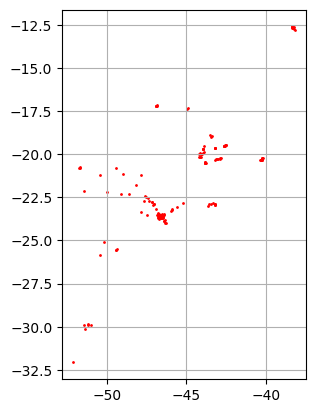

In [ ]:
estacoes = estacoes_gpd.plot(color = 'red', markersize = 1)
estacoes.grid(True)

<function matplotlib.pyplot.show(close=None, block=None)>

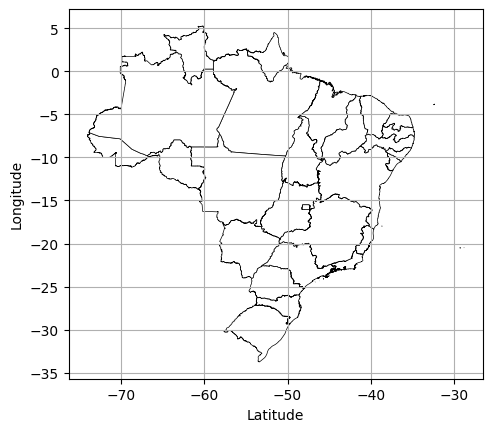

In [ ]:
#Plotando o Brasil.
Brasil_file = gpd.read_file('/content/BR_UF_2024.zip')

Brasil = Brasil_file.plot(facecolor='white', edgecolor='black', linewidth=0.5)
Brasil.grid(True)
Brasil.set_xlabel('Latitude')
Brasil.set_ylabel('Longitude')

plt.show

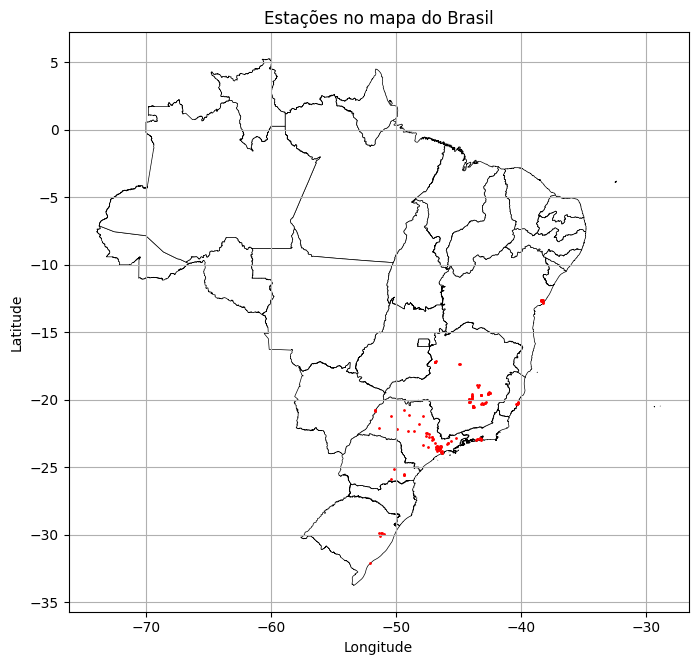

In [ ]:
fig, ax = plt.subplots(figsize=(8,10))

Brasil_file.plot(ax = ax, facecolor='white', edgecolor='black', linewidth=0.5)
estacoes_gpd.plot(ax = ax, color = 'red', markersize = 1)

ax.set_title("Estações de Monitoramento no Brasil")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.grid(True)

ax.set_title('Estações no mapa do Brasil')
plt.show()